In [ ]:
#Nicholas Garcia & Gabriel Garcia-Machorro

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
#https://www.kaggle.com/datasets/ayeshasiddiqa123/student-perfirmance

In [2]:
from google.colab import files
uploaded=files.upload()
df=pd.read_csv('StudentPerformanceFactors.csv')
df.head()
#Uploading my new dataset
#dataset on student performance

Saving StudentPerformanceFactors.csv to StudentPerformanceFactors.csv


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [3]:
df.isnull().sum() #showing the number nulls for each column

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


In [4]:
df.fillna(value=0, inplace=True) #replacing null values with zero
df

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68


In [5]:
df.isnull().sum() # showing again null values
#there are no more null values

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


In [6]:
#Dropping all columns that do not contain continous values
df.drop("Parental_Involvement", axis=1, inplace=True)
df.drop("Access_to_Resources", axis=1, inplace=True)
df.drop("Motivation_Level", axis=1, inplace=True)
df.drop("Family_Income", axis=1, inplace=True)
df.drop("Teacher_Quality", axis=1, inplace=True)
df.drop("School_Type", axis=1, inplace=True )
df.drop("Peer_Influence", axis=1, inplace=True)
df.drop("Parental_Education_Level", axis=1, inplace=True)
df.drop("Distance_from_Home", axis=1, inplace=True)
df.drop("Gender", axis=1, inplace=True)

In [7]:
#dropping more columns
df.drop("Extracurricular_Activities", axis=1, inplace=True)
df.drop("Internet_Access", axis=1, inplace=True)
df.drop("Learning_Disabilities", axis=1, inplace=True)

In [8]:
df.head(100) # double checking all columns were dropped

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
0,23,84,7,73,0,3,67
1,19,64,8,59,2,4,61
2,24,98,7,91,2,4,74
3,29,89,8,98,1,4,71
4,19,92,6,65,3,4,70
...,...,...,...,...,...,...,...
95,11,91,6,94,3,3,68
96,22,64,7,98,1,3,62
97,22,81,7,77,2,3,68
98,20,69,6,73,2,3,66


In [9]:
#One hot coding was not needed in this dataset as it does not apply and wont work with this specific continous data
#Label Encoder does not apply to this data set so we only dropped certain columns that were not continous
#Data Normalization wont really work as the value do not really over value each other so they do not need to be standardized

In [10]:
#reorganizing the columns to a certain order
old_cols=df.columns.values
new_cols=['Hours_Studied', 'Attendance', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Sleep_Hours', 'Exam_Score' ]
df=df.reindex(columns=new_cols)
df

,Hours_Studied,Attendance,Previous_Scores,Tutoring_Sessions,Physical_Activity,Sleep_Hours,Exam_Score
0,23,84,73,0,3,7,67
1,19,64,59,2,4,8,61
2,24,98,91,2,4,7,74
3,29,89,98,1,4,8,71
4,19,92,65,3,4,6,70
...,...,...,...,...,...,...,...
6602,25,69,76,1,2,7,68
6603,23,76,81,3,2,8,69
6604,20,90,65,3,2,6,68
6605,10,86,91,2,3,6,68


In [11]:
print(df.rename(columns={'Sleep_Hours':'Hours_Of_Sleep'})) # renaming sleep hours columns

      Hours_Studied  Attendance  Previous_Scores  Tutoring_Sessions  \
0                23          84               73                  0   
1                19          64               59                  2   
2                24          98               91                  2   
3                29          89               98                  1   
4                19          92               65                  3   
...             ...         ...              ...                ...   
6602             25          69               76                  1   
6603             23          76               81                  3   
6604             20          90               65                  3   
6605             10          86               91                  2   
6606             15          67               94                  0   

      Physical_Activity  Hours_Of_Sleep  Exam_Score  
0                     3               7          67  
1                     4               8

Text(0, 0.5, 'Final Exam Score')

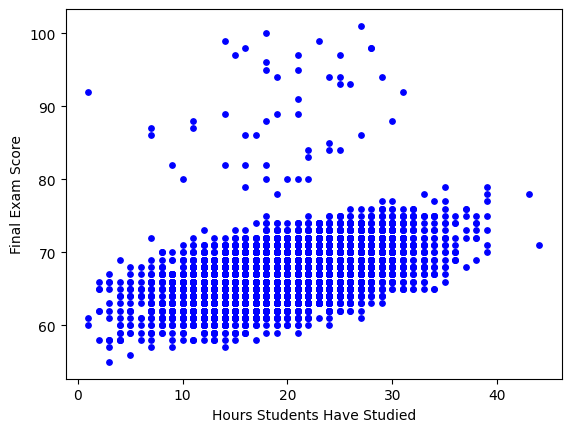

In [14]:
#making a scatter plot with blue dots and dot size 15
#inserting data from hours_studied and exam_score columns
plt.scatter(df['Hours_Studied'],df['Exam_Score'],c='blue', s=15)
#making labels for x and y axis
plt.xlabel('Hours Students Have Studied')
plt.ylabel('Final Exam Score')

In [15]:
k=2
#k is 2 because there is only 2 columns
#its how many clusters you want
X=np.array(list(zip(df['Hours_Studied'],df['Exam_Score']))) #creates a matrix with all points
model=KMeans(n_clusters=k)#creating a model variable
kmeans=model.fit(X)  #the fit function trains the model and its perameters
labels=model.predict(X) #predict function assigns all a label to all points
centroids=model.cluster_centers_ #indentifies the centroids
print(labels) #prints the labels and centroids of the clusters
print(centroids)

[1 0 1 ... 1 0 0]
[[15.22678517 65.38369599]
 [24.60885167 69.04276316]]


Text(0, 0.5, 'Final Exam Score')

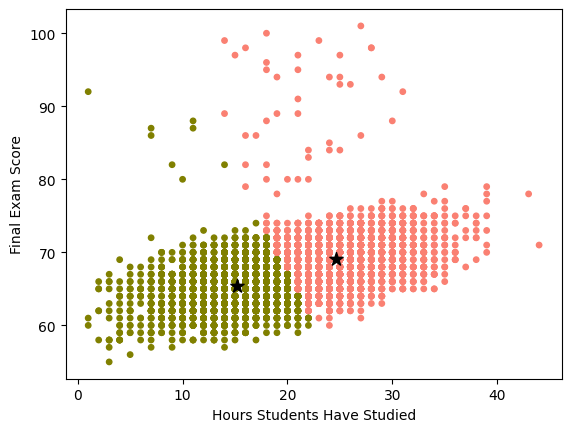

In [16]:
c=['olive','salmon','yellow', 'green'] #Plots the points and centroids of each cluster
colors=[c[i]for i in labels] #maps the labels in colors

plt.scatter(df['Hours_Studied'],df['Exam_Score'], c=colors, s=15)
plt.scatter(centroids[:,0], centroids[:,1], marker='*', s=100, c='black')
plt.xlabel('Hours Students Have Studied')
plt.ylabel('Final Exam Score')

In [17]:
#Making predictions off the cluster model we just trained
cluster=model.predict([[8,71]])[0]
print(c[cluster])

cluster=model.predict([[14,60]])[0]
print(c[cluster])

olive
olive


In [19]:
from sklearn.metrics import silhouette_score
model=KMeans(n_clusters=2)
model.fit(X)
label=model.predict(X)
print(f'silhouette Score (n-2):  {silhouette_score(X,label)}')

model=KMeans(n_clusters=3)
model.fit(X)
label=model.predict(X)
print(f'silhouette Score (n-2):  {silhouette_score(X,label)}')
#Gives you the silhouette coefficient score
#changing the n_clusters to 3 to see the score difference

silhouette Score (n-2):  0.4277899722555959
silhouette Score (n-2):  0.3660293209077088


The data set I decided to choose is about students taking an exam with various data effecting the outcome of their exam score. We decided to focus on the hours studied and the final exam scores. This algorithm seperated both groups as shown on the plot chart with with average for each group. The olive color is the hours studied and the salmon color is their final exam score. The average student studied around 15 hours and got a average score of 69 for the exam, at least thats what the data tells us. We decided to test how well these two groups work with each other and if they fit with each other. We got a score of 0.42 out of 1, this means that their could have been other factors or groups that could have been added like hours slept or how good their attendance was. The ideal score is to get as close to 1 as possible because it shows how accurate the dataset is to whatever goal your trying to reach